# Manuscript figures — capsule sponge supernatant REG4/FABP2 SIMOA assay

Reproduces every data panel in the main manuscript from the files in `data/`. The model is **never refitted**
for evaluation: every probability comes from the locked two-marker equation in
`model/locked_model_coefficients.json`,

$$\mathrm{logit}(P) = -1.3759 + 2.4155\,\ln(1+\mathrm{REG4}) + 0.7948\,\ln(1+\mathrm{FABP2}) \quad [\text{ng/mL}]$$

The only fitting in this notebook is (i) 5-fold cross-validation inside the training cohort for the
out-of-fold training ROC (Fig. 3E), and (ii) the SHAP explanation in Fig. 3A.

| Panel | Data file | Content |
|---|---|---|
| 3A | `Fig3A_SHAP_three_SIMOA_markers.csv` | SHAP, SIMOA REG4/FABP2/TFF3, training cohort |
| 3B | `Fig3B_training_cohort.csv` | REG4 and FABP2, training cohort (n = 134) |
| 3C | `Fig3C_dysplasia_cohort.csv` | REG4 and FABP2, dysplasia cohort (n = 164) |
| 3D | `Fig3D_prospective_cohort.csv` | REG4 and FABP2, prospective cohort (n = 121) |
| 3E | 3B + 3C + 3D files | ROC curves, all three cohorts |
| 4A | `Fig4A_segment_length.csv` | REG4 and FABP2 by Prague M category |
| 4B, 4C | `Fig3C_dysplasia_cohort.csv` | Confidence tiers; every high-grade case |

**Not generated here:** Fig. 1 (bulk RNA-seq, scRNA-seq, Xenium), Fig. 2 (IHC and Xenium) and Fig. 5
(BioRender schematic) come from separate pipelines.

Cohort names are descriptive (*training*, *dysplasia*, *prospective*) on purpose, because the draft uses
"test" and "validation" in opposite senses in different places. Set `fh.SAVE = True` below to write every
panel to `figures/` as a 600-dpi TIFF and an editable SVG.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve
import figure_helpers as fh
from figure_helpers import *

fh.SAVE = False        # True -> write TIFF + SVG for every panel into ./figures

TR = load("Fig3B_training_cohort")
DY = load("Fig3C_dysplasia_cohort")
PR = load("Fig3D_prospective_cohort")
for d in (TR, DY, PR):
    d["p"] = locked_probability(d.SIMOA_REG4, d.SIMOA_FABP2)
    d["tier"] = tier(d.p)

# Dysplasia-cohort groups used in Fig. 3C. One BE case has no histological grade recorded; the
# manuscript counts it as NDBE (56 NDBE), so it is grouped with NDBE here and flagged.
DY["group"] = np.where(DY.BE == 0, "Heartburn",
               np.where(DY.diagnosis.isin(["NDBE", "BE, grade not recorded"]), "NDBE", "IND–OAC"))

print(f"training    n = {len(TR)}  ({TR.BE.sum()} BE / {(TR.BE==0).sum()} controls); "
      f"{(TR.study_source!='prospective').sum()} archival BEST2/DELTA samples")
print(f"dysplasia   n = {len(DY)}  ({DY.BE.sum()} BE / {(DY.BE==0).sum()} controls)")
print("            " + ", ".join(f"{k} {v}" for k, v in DY.diagnosis.value_counts().items()))
print(f"prospective n = {len(PR)}  ({PR.BE.sum()} BE / {(PR.BE==0).sum()} controls); "
      f"{PR.also_in_dysplasia_cohort.sum()} patients also appear in the dysplasia cohort")
print(f"\nlocked model: logit(P) = {B0:+.4f} {B_REG4:+.4f}·ln(1+REG4) {B_FABP2:+.4f}·ln(1+FABP2)")
print(f"floor probability (both markers 0 ng/mL) = {1/(1+np.exp(-B0)):.3f}")
print(f"tiers: rule-out P < {T_OUT:.3f} | indeterminate | rule-in P ≥ {T_IN:.3f}   (derived on the prospective cohort)")

training    n = 134  (64 BE / 70 controls); 19 archival BEST2/DELTA samples
dysplasia   n = 164  (98 BE / 66 controls)
            Heartburn 66, NDBE 55, IND 23, LGD 14, HGD 4, OAC 1, BE, grade not recorded 1
prospective n = 121  (64 BE / 57 controls); 7 patients also appear in the dysplasia cohort

locked model: logit(P) = -1.3759 +2.4155·ln(1+REG4) +0.7948·ln(1+FABP2)
floor probability (both markers 0 ng/mL) = 0.202
tiers: rule-out P < 0.462 | indeterminate | rule-in P ≥ 0.748   (derived on the prospective cohort)


## Figure 3A — SHAP, three SIMOA analytes (training cohort)
The locked model family refitted on REG4, FABP2 and TFF3 to show why TFF3 was dropped.

{'TFF3': np.float64(0.453), 'FABP2': np.float64(1.071), 'REG4': np.float64(1.545)}


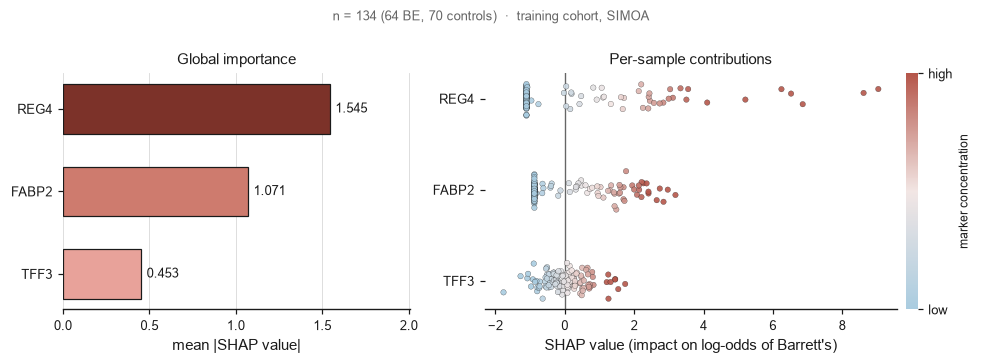

In [2]:
S3 = load("Fig3A_SHAP_three_SIMOA_markers")
fig, imp = shap_panel(S3[["SIMOA_REG4", "SIMOA_FABP2", "SIMOA_TFF3"]], S3.BE.values,
                      ["REG4", "FABP2", "TFF3"], "  ·  training cohort, SIMOA")
print({k: round(v, 3) for k, v in imp.items()})
save(fig, "Fig3A_SHAP_three_SIMOA_markers"); plt.show()

## Figure 3B — training cohort
Two-sided Mann–Whitney U, BE vs heartburn. The y-axis is log10(1 + ng/mL) for display only; the model uses ln(1 + ng/mL).

  Training cohort        REG4  BE vs heartburn  Mann–Whitney P = 4.97e-14
  Training cohort        FABP2 BE vs heartburn  Mann–Whitney P = 2.76e-12


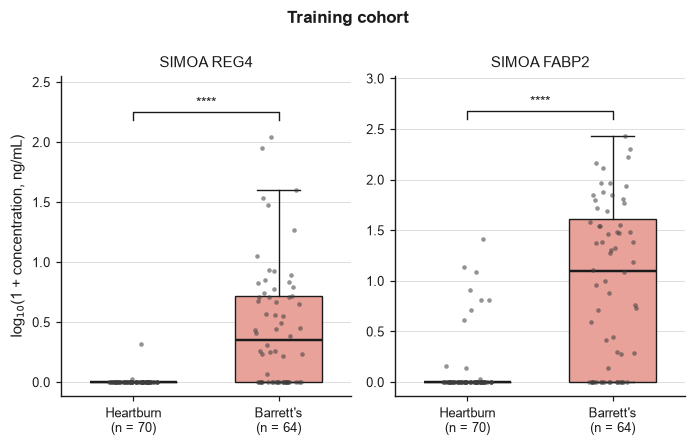

In [3]:
def two_group(df, title, name):
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.0))
    for ax, m, lab in zip(axes, ["SIMOA_REG4", "SIMOA_FABP2"], ["REG4", "FABP2"]):
        g = [df.loc[df.BE == 0, m], df.loc[df.BE == 1, m]]
        d = box_strip(ax, g, ["Heartburn", "Barrett's"], [C_CTRL, C_BE],
                      ylabel="log$_{10}$(1 + concentration, ng/mL)" if m == "SIMOA_REG4" else "", title=f"SIMOA {lab}")
        p = mwu(*g); top = max(map(np.max, d))
        bracket(ax, 0, 1, top * 1.06 + 0.02, p, h=top * 0.03 + 0.01)
        ax.set_ylim(top=top * 1.2 + 0.1)
        print(f"  {title:22s} {lab:5s} BE vs heartburn  Mann–Whitney P = {fmt_p(p)}")
    fig.suptitle(title, fontweight="bold", y=1.0); fig.tight_layout()
    save(fig, name); plt.show()

two_group(TR, "Training cohort", "Fig3B_training_cohort")

## Figure 3C — dysplasia cohort
Kruskal–Wallis with Dunn's test (Benjamini–Hochberg) for the brackets, as stated in Methods. The unadjusted
Mann–Whitney P values quoted in the Results text are printed underneath. "IND–OAC" = indefinite for dysplasia,
LGD, HGD and OAC (n = 42) — the draft labels this group "dysplasia", but 23 of the 42 are IND.

REG4: Dunn–BH Heartburn vs NDBE 0.0026, Heartburn vs IND–OAC 3.72e-07, NDBE vs IND–OAC 0.02
      Mann–Whitney (unadjusted): all BE vs HB 1.24e-06; NDBE vs HB 8.44e-05; IND–OAC vs HB 4.62e-08; IND–OAC vs NDBE 0.042
FABP2: Dunn–BH Heartburn vs NDBE 9.11e-13, Heartburn vs IND–OAC 4.08e-12, NDBE vs IND–OAC 0.79
      Mann–Whitney (unadjusted): all BE vs HB 2.51e-17; NDBE vs HB 7.94e-14; IND–OAC vs HB 1.28e-11; IND–OAC vs NDBE 0.61


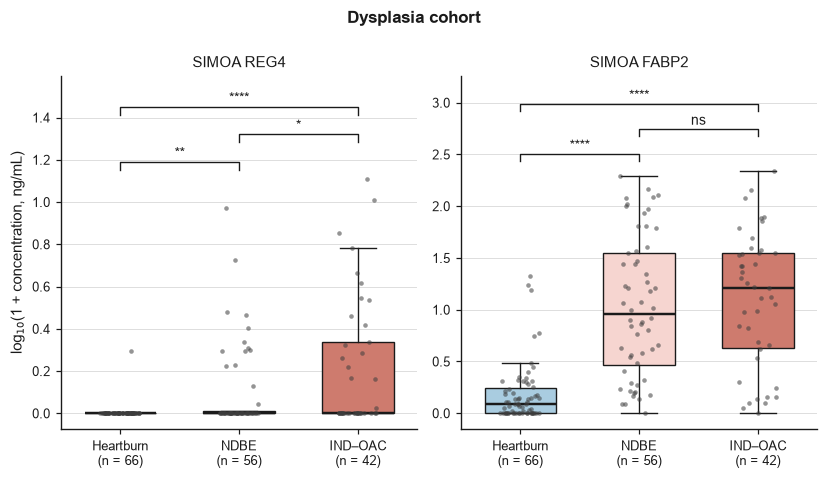


Prague M, NDBE vs IND–OAC: median 3 vs 5 cm, Mann–Whitney P = 0.065  (segment length is a candidate confounder of the REG4 difference)


In [4]:
labs = ["Heartburn", "NDBE", "IND–OAC"]; cols = [C_CTRL, C_NDBE, C_DYS]
fig, axes = plt.subplots(1, 2, figsize=(7.6, 4.3))
for ax, m, lab in zip(axes, ["SIMOA_REG4", "SIMOA_FABP2"], ["REG4", "FABP2"]):
    g = [DY.loc[DY.group == k, m] for k in labs]
    d = box_strip(ax, g, labs, cols, ylabel="log$_{10}$(1 + concentration, ng/mL)" if lab == "REG4" else "",
                  title=f"SIMOA {lab}")
    adj = dunn_bh(g, labs); top = max(map(np.max, d)); step = top * 0.09 + 0.03
    for k, (a, b) in enumerate([("Heartburn", "NDBE"), ("NDBE", "IND–OAC"), ("Heartburn", "IND–OAC")]):
        bracket(ax, labs.index(a), labs.index(b), top * 1.04 + k * step, adj[(a, b)], h=top * 0.025 + 0.01)
    ax.set_ylim(top=top * 1.04 + 3.4 * step)
    print(f"{lab}: Dunn–BH " + ", ".join(f"{a} vs {b} {fmt_p(q)}" for (a, b), q in adj.items()))
    hb, be = DY.loc[DY.BE == 0, m], DY.loc[DY.BE == 1, m]
    print(f"      Mann–Whitney (unadjusted): all BE vs HB {fmt_p(mwu(be, hb))}; "
          + "; ".join(f"{k} vs HB {fmt_p(mwu(DY.loc[DY.group==k, m], hb))}" for k in labs[1:])
          + f"; IND–OAC vs NDBE {fmt_p(mwu(g[2], g[1]))}")
fig.suptitle("Dysplasia cohort", fontweight="bold", y=1.0); fig.tight_layout()
save(fig, "Fig3C_dysplasia_cohort"); plt.show()

nd, dy = DY[DY.group == "NDBE"], DY[DY.group == "IND–OAC"]
print(f"\nPrague M, NDBE vs IND–OAC: median {nd.prague_M.median():.0f} vs {dy.prague_M.median():.0f} cm, "
      f"Mann–Whitney P = {fmt_p(mwu(nd.prague_M, dy.prague_M))}  (segment length is a candidate confounder of the REG4 difference)")

## Figure 3D — prospective cohort

  Prospective cohort     REG4  BE vs heartburn  Mann–Whitney P = 1.65e-14
  Prospective cohort     FABP2 BE vs heartburn  Mann–Whitney P = 1.03e-12


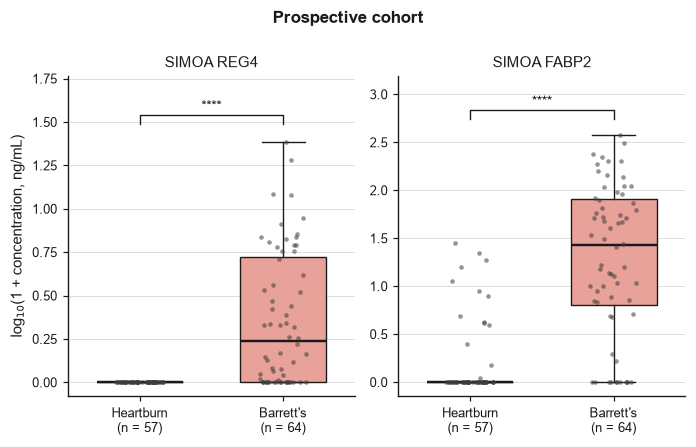


BEST4 arm by diagnosis (all cases Surveillance, all controls Screening):
BE            BE  heartburn
BEST4_arm                  
Screening      0         57
Surveillance  64          0


In [5]:
two_group(PR, "Prospective cohort", "Fig3D_prospective_cohort")
print(f"\nBEST4 arm by diagnosis (all cases Surveillance, all controls Screening):")
print(pd.crosstab(PR.BEST4_arm, PR.BE.map({0: 'heartburn', 1: 'BE'})).to_string())

## Figure 3E — ROC curves, three cohorts
Training: 5-fold stratified out-of-fold predictions (the model refitted within each fold). Dysplasia and
prospective cohorts: the locked model, unchanged. Open circles mark the prespecified threshold, P = 0.50.

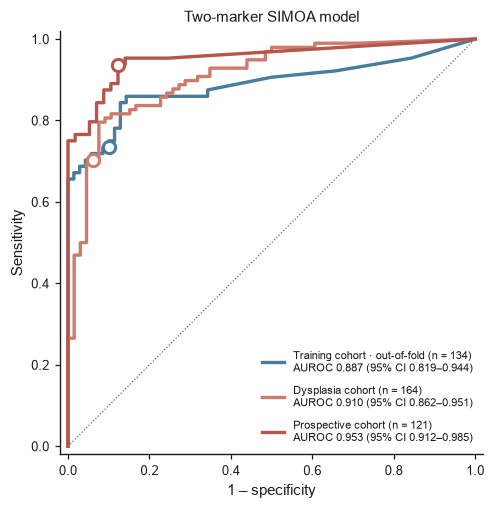

Training cohort · out-of-fold      n=134 (64 BE / 70 controls)  AUROC 0.887 (0.819-0.944)  sens 73.4% (62%-83%)  spec 90.0% (81%-95%)  PPV 87.0%  NPV 78.8%
Dysplasia cohort                   n=164 (98 BE / 66 controls)  AUROC 0.910 (0.862-0.951)  sens 70.4% (61%-79%)  spec 93.9% (85%-98%)  PPV 94.5%  NPV 68.1%
Prospective cohort                 n=121 (64 BE / 57 controls)  AUROC 0.953 (0.912-0.985)  sens 93.8% (85%-98%)  spec 87.7% (77%-94%)  PPV 89.6%  NPV 92.6%


Training · apparent (not OOF)      n=134 (64 BE / 70 controls)  AUROC 0.906 (0.851-0.951)  sens 78.1% (67%-86%)  spec 90.0% (81%-95%)  PPV 87.7%  NPV 81.8%


In [6]:
yt = TR.BE.values; oof = np.zeros(len(TR))
for a, b in StratifiedKFold(5, shuffle=True, random_state=0).split(TR, yt):
    oof[b] = make_pipeline(["SIMOA_REG4", "SIMOA_FABP2"]).fit(TR.iloc[a], yt[a]).predict_proba(TR.iloc[b])[:, 1]
TR["p_oof"] = oof

COH = [("Training cohort · out-of-fold", yt, oof, E_CTRL),
       ("Dysplasia cohort", DY.BE.values, DY.p.values, RAMP[3]),
       ("Prospective cohort", PR.BE.values, PR.p.values, E_BE)]
fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.plot([0, 1], [0, 1], color=MUTED, lw=0.8, ls=":")
RES = {}
for lab, y, p, c in COH:
    r = performance(y, p); RES[lab] = r
    f, t, _ = roc_curve(y, p)
    ax.plot(f, t, color=c, lw=2.2, label=f"{lab} (n = {r['n']})\nAUROC {r['auc']:.3f} (95% CI {r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f})")
    ax.plot(1 - r["spec"], r["sens"], "o", ms=8, mfc=SURF, mec=c, mew=2, zorder=5)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
ax.set_xlabel("1 – specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("Two-marker SIMOA model")
ax.legend(loc="lower right", fontsize=7.4, labelspacing=0.9)
save(fig, "Fig3E_ROC_three_cohorts"); plt.show()

for lab, r in RES.items(): report(lab, r)
report("Training · apparent (not OOF)", performance(yt, TR.p.values))

## Figure 4A — REG4 and FABP2 by segment length
Dysplasia and prospective cohorts pooled, Barrett's cases grouped by Prague M. The draft figure overlaid both
markers inside a single box per category; here each marker has its own box so the medians are interpretable.

REG4: BE only, Kruskal–Wallis P = 0.0059; Spearman vs Prague M rho = 0.26, P = 0.0011
   Dunn–BH: short–medium 0.013, short–long 0.013, short–super long 0.64
   Mann–Whitney vs short (unadjusted): medium 0.0038, long 0.0018, super long 0.59
FABP2: BE only, Kruskal–Wallis P = 0.2; Spearman vs Prague M rho = 0.17, P = 0.032
   Dunn–BH: short–medium 0.5, short–long 0.32, short–super long 0.32
   Mann–Whitney vs short (unadjusted): medium 0.45, long 0.16, super long 0.044


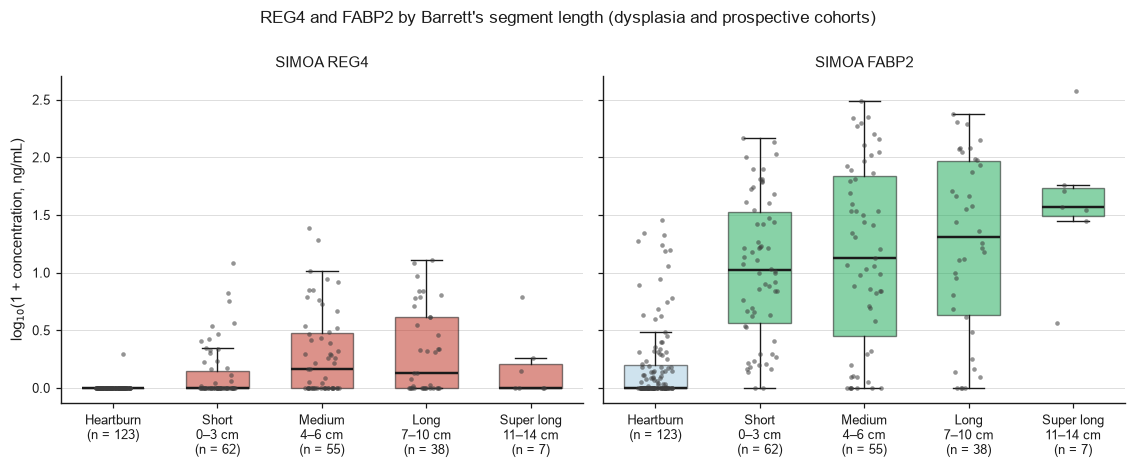

In [7]:
SL = load("Fig4A_segment_length")
cats = ["Heartburn", "Short\n0–3 cm", "Medium\n4–6 cm", "Long\n7–10 cm", "Super long\n11–14 cm"]
SL["cat"] = np.where(SL.BE == 0, cats[0],
            pd.cut(SL.prague_M, [-0.1, 3, 6, 10, 20], labels=cats[1:]).astype(object))
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), sharey=True)
for ax, m, lab, c in zip(axes, ["SIMOA_REG4", "SIMOA_FABP2"], ["REG4", "FABP2"], [C_REG4, C_FABP2]):
    g = [SL.loc[SL.cat == k, m] for k in cats]
    box_strip(ax, g, cats, [C_CTRL] + [c] * 4, ylabel="log$_{10}$(1 + concentration, ng/mL)" if lab == "REG4" else "",
              title=f"SIMOA {lab}")
    for patch in ax.patches: patch.set_alpha(0.55)
    be = [SL.loc[SL.cat == k, m] for k in cats[1:]]
    kw = stats.kruskal(*[x.dropna() for x in be]).pvalue
    adj = dunn_bh(be, ["short", "medium", "long", "super long"])
    rho, prho = stats.spearmanr(SL.loc[SL.BE == 1, "prague_M"], SL.loc[SL.BE == 1, m], nan_policy="omit")
    print(f"{lab}: BE only, Kruskal–Wallis P = {fmt_p(kw)}; Spearman vs Prague M rho = {rho:.2f}, P = {fmt_p(prho)}")
    print("   Dunn–BH: " + ", ".join(f"{a}–{b} {fmt_p(q)}" for (a, b), q in adj.items() if a == "short"))
    print("   Mann–Whitney vs short (unadjusted): " + ", ".join(
        f"{k.split(chr(10))[0].lower()} {fmt_p(mwu(be[0], x))}" for k, x in zip(cats[2:], be[1:])))
fig.suptitle("REG4 and FABP2 by Barrett's segment length (dysplasia and prospective cohorts)", y=1.0)
fig.tight_layout(); save(fig, "Fig4A_segment_length"); plt.show()

## Figure 4B — confidence tiers, dysplasia cohort
The tier thresholds were derived on the **prospective** cohort (rule-out: the highest threshold keeping
sensitivity ≥ 95%; rule-in: the lowest keeping specificity ≥ 98%) and applied unchanged to the dysplasia
cohort. They are re-derived below from `Fig3D_prospective_cohort.csv` to show that.

re-derived on prospective cohort: rule-out 0.4622 (locked 0.4622), rule-in 0.7485 (locked 0.7485)


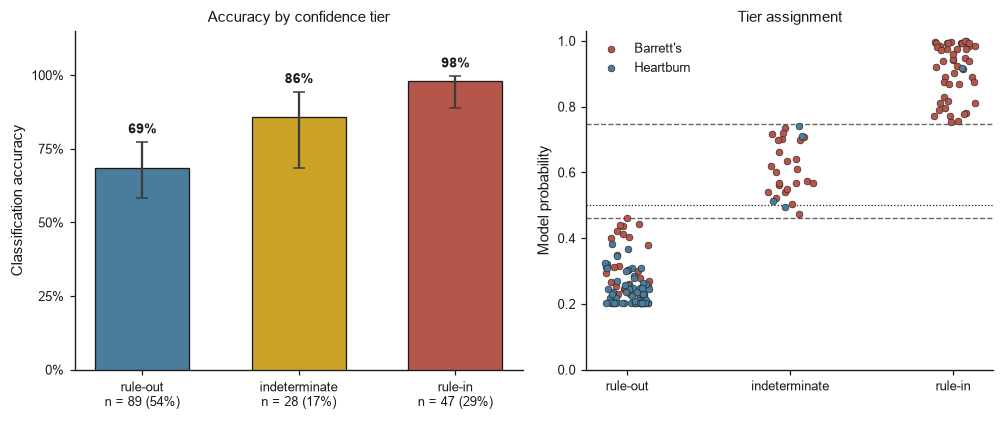

                  cohort          tier  n share  BE  heartburn accuracy
prospective (derivation)      rule-out 52   43%   3         49    94.2%
prospective (derivation) indeterminate 19   16%  12          7    63.2%
prospective (derivation)       rule-in 50   41%  49          1    98.0%
     dysplasia (applied)      rule-out 89   54%  28         61    68.5%
     dysplasia (applied) indeterminate 28   17%  24          4    85.7%
     dysplasia (applied)       rule-in 47   29%  46          1    97.9%
  prospective  rule-in PPV 49/50 = 98.0%;  rule-out NPV 49/52 = 94.2%
  dysplasia    rule-in PPV 46/47 = 97.9%;  rule-out NPV 61/89 = 68.5%


In [8]:
f, t, th = roc_curve(PR.BE, PR.p)
print(f"re-derived on prospective cohort: rule-out {float(max(th[t >= .95])):.4f} (locked {T_OUT:.4f}), "
      f"rule-in {float(min(th[(1 - f) >= .98])):.4f} (locked {T_IN:.4f})")

TI = ["rule-out", "indeterminate", "rule-in"]
DY["correct"] = ((DY.p >= THR).astype(int) == DY.BE)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]; acc, err, n = [], [[], []], []
for k in TI:
    s = DY[DY.tier == k]; a = s.correct.mean(); lo, hi = wilson(int(s.correct.sum()), len(s))
    acc.append(a); err[0].append(a - lo); err[1].append(hi - a); n.append(len(s))
ax.bar(range(3), acc, 0.6, color=[TIER_COL[k] for k in TI], edgecolor=INK, lw=0.85, zorder=3)
ax.errorbar(range(3), acc, yerr=err, fmt="none", ecolor=PT, capsize=4, zorder=4)
for i in range(3):
    ax.text(i, acc[i] + err[1][i] + 0.03, f"{acc[i]:.0%}", ha="center", fontweight="bold")
ax.set_xticks(range(3)); ax.set_xticklabels([f"{k}\nn = {c} ({c/len(DY):.0%})" for k, c in zip(TI, n)])
ax.set_ylim(0, 1.15); ax.set_yticks(np.arange(0, 1.01, .25)); ax.set_yticklabels([f"{v:.0%}" for v in np.arange(0, 1.01, .25)])
ax.set_ylabel("Classification accuracy"); ax.set_title("Accuracy by confidence tier")
ax = axes[1]; rng = np.random.default_rng(1)
for i, k in enumerate(TI):
    for y, c, lab in [(1, E_BE, "Barrett's"), (0, E_CTRL, "Heartburn")]:
        s = DY[(DY.tier == k) & (DY.BE == y)]
        ax.scatter(i + rng.uniform(-.14, .14, len(s)), s.p, s=20, color=c, edgecolor=INK, lw=.35,
                   label=lab if i == 0 else None, zorder=3)
for v in (T_OUT, T_IN): ax.axhline(v, color=MUTED, lw=.9, ls="--")
ax.axhline(THR, color=INK, lw=.8, ls=":")
ax.set_xticks(range(3)); ax.set_xticklabels(TI); ax.set_ylim(0, 1.03)
ax.set_ylabel("Model probability"); ax.set_title("Tier assignment"); ax.legend(loc="upper left")
fig.tight_layout(); save(fig, "Fig4B_confidence_tiers"); plt.show()

rows = []
for nm, d in [("prospective (derivation)", PR), ("dysplasia (applied)", DY)]:
    for k in TI:
        s = d[d.tier == k]
        rows.append(dict(cohort=nm, tier=k, n=len(s), share=f"{len(s)/len(d):.0%}", BE=int(s.BE.sum()),
                         heartburn=int((s.BE == 0).sum()), accuracy=f"{((s.p>=THR).astype(int)==s.BE).mean():.1%}"))
tiers = pd.DataFrame(rows); print(tiers.to_string(index=False))
for nm, d in [("prospective", PR), ("dysplasia", DY)]:
    ri, ro = d[d.tier == "rule-in"], d[d.tier == "rule-out"]
    print(f"  {nm:12s} rule-in PPV {int(ri.BE.sum())}/{len(ri)} = {ri.BE.mean():.1%};  rule-out NPV {int((ro.BE==0).sum())}/{len(ro)} = {(ro.BE==0).mean():.1%}")

## Figure 4C — every high-grade case in the dysplasia cohort
Descriptive only. REG4 is 0 ng/mL in all five, but this holds only in the refined cohort: in the all-comers
cohort (n = 179) REG4 was undetectable in 9/11 high-grade vs 68/101 other BE cases (Fisher P = 0.50); see the
supplementary notebook, section S8.

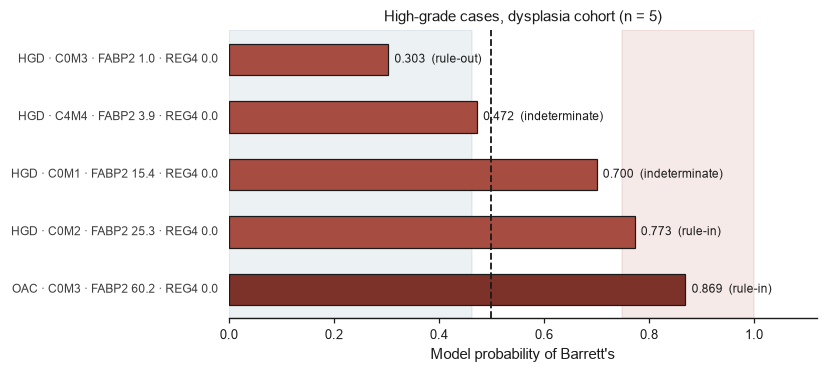

diagnosis  prague_C  prague_M  SIMOA_REG4  SIMOA_FABP2     p          tier
      HGD       0.0       3.0         0.0        0.985 0.303      rule-out
      HGD       4.0       4.0         0.0        3.913 0.472 indeterminate
      HGD       0.0       1.0         0.0       15.411 0.700 indeterminate
      HGD       0.0       2.0         0.0       25.308 0.773       rule-in
      OAC       0.0       3.0         0.0       60.248 0.869       rule-in


In [9]:
hg = DY[DY.diagnosis.isin(["HGD", "OAC"])].sort_values("p").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(6.9, 3.4)); y = np.arange(len(hg))[::-1]
ax.axvspan(0, T_OUT, color=E_CTRL, alpha=.10); ax.axvspan(T_IN, 1, color=E_BE, alpha=.12)
ax.barh(y, hg.p, .55, color=[RAMP[4] if g == "HGD" else RAMP[5] for g in hg.diagnosis], edgecolor=INK, lw=.8, zorder=3)
ax.axvline(THR, color=INK, lw=1.2, ls="--", zorder=4)
for yy, (_, r) in zip(y, hg.iterrows()):
    ax.text(r.p + .012, yy, f"{r.p:.3f}  ({r.tier})", va="center", fontsize=8)
    ax.text(-.02, yy, f"{r.diagnosis} · C{r.prague_C:.0f}M{r.prague_M:.0f} · FABP2 {r.SIMOA_FABP2:.1f} · REG4 {r.SIMOA_REG4:.1f}",
            va="center", ha="right", fontsize=7.8, color=PT)
ax.set_yticks([]); ax.set_xlim(0, 1.12); ax.spines[["left"]].set_visible(False)
ax.set_xlabel("Model probability of Barrett's"); ax.set_title(f"High-grade cases, dysplasia cohort (n = {len(hg)})")
save(fig, "Fig4C_high_grade_cases"); plt.show()
print(hg[["diagnosis", "prague_C", "prague_M", "SIMOA_REG4", "SIMOA_FABP2", "p", "tier"]].round(3).to_string(index=False))

## Numbers quoted in the Results and Discussion
One table with every performance figure the text cites, so the manuscript can be checked against it. It is
written to `tables/Manuscript_numbers.csv`.

In [10]:
def row(label, y, p):
    r = performance(y, p)
    return {"analysis": label, "n": r["n"], "BE": r["BE"], "controls": r["controls"],
            "AUROC (95% CI)": f"{r['auc']:.3f} ({r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f})",
            "sensitivity (95% CI)": f"{r['sens']:.1%} ({r['sens_ci'][0]:.0%}–{r['sens_ci'][1]:.0%})",
            "specificity (95% CI)": f"{r['spec']:.1%} ({r['spec_ci'][0]:.0%}–{r['spec_ci'][1]:.0%})",
            "PPV": f"{r['ppv']:.1%}", "NPV": f"{r['npv']:.1%}"}
hb = DY[DY.BE == 0]
sub = lambda keep: pd.concat([hb, DY[keep]])
N = [row("Training, out-of-fold", TR.BE, TR.p_oof),
     row("Dysplasia cohort, all BE vs heartburn", DY.BE, DY.p),
     row("  NDBE vs heartburn", *(lambda s: (s.BE, s.p))(sub(DY.group == "NDBE"))),
     row("  IND–OAC vs heartburn", *(lambda s: (s.BE, s.p))(sub(DY.group == "IND–OAC"))),
     row("  LGD/HGD/OAC vs heartburn", *(lambda s: (s.BE, s.p))(sub(DY.diagnosis.isin(["LGD", "HGD", "OAC"])))),
     row("Prospective cohort", PR.BE, PR.p),
     row("  excluding 7 patients also in dysplasia cohort", PR[PR.also_in_dysplasia_cohort == 0].BE,
         PR[PR.also_in_dysplasia_cohort == 0].p)]
NUM = pd.DataFrame(N); TABLES.mkdir(exist_ok=True); NUM.to_csv(TABLES / "Manuscript_numbers.csv", index=False)
NUM

,analysis,n,BE,controls,AUROC (95% CI),sensitivity (95% CI),specificity (95% CI),PPV,NPV
0,"Training, out-of-fold",134,64,70,0.887 (0.819–0.944),73.4% (62%–83%),90.0% (81%–95%),87.0%,78.8%
1,"Dysplasia cohort, all BE vs heartburn",164,98,66,0.910 (0.862–0.951),70.4% (61%–79%),93.9% (85%–98%),94.5%,68.1%
2,NDBE vs heartburn,122,56,66,0.910 (0.852–0.955),66.1% (53%–77%),93.9% (85%–98%),90.2%,76.5%
3,IND–OAC vs heartburn,108,42,66,0.910 (0.842–0.967),76.2% (61%–87%),93.9% (85%–98%),88.9%,86.1%
4,LGD/HGD/OAC vs heartburn,85,19,66,0.907 (0.819–0.981),73.7% (51%–88%),93.9% (85%–98%),77.8%,92.5%
5,Prospective cohort,121,64,57,0.953 (0.912–0.985),93.8% (85%–98%),87.7% (77%–94%),89.6%,92.6%
6,excluding 7 patients also in dysplasia cohort,114,57,57,0.948 (0.900–0.983),93.0% (83%–97%),87.7% (77%–94%),88.3%,92.6%
